In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving data.csv to data.csv


In [4]:
filename = next(iter(uploaded))

df = pd.read_csv(filename, header=None)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6900, 257)


,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,256
0,0,94,96,5,0,-11,9,-12,8,-9,...,-38,24,-36,24,-33,22,-34,19,-33,14
1,0,96,-128,5,0,11,-21,9,-20,8,...,33,-44,32,-43,29,-43,26,-43,23,-44
2,0,96,-128,5,0,5,23,5,20,5,...,4,26,3,25,4,24,4,23,4,21
3,0,96,-128,5,0,17,2,17,2,17,...,45,17,44,15,45,13,45,13,45,11
4,0,96,-128,5,0,15,5,14,4,13,...,40,25,39,22,40,20,38,18,35,17


In [5]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df[0].value_counts().sort_index())

Dataset Shape: (6900, 257)

Missing Values:
0

Class Distribution:
0
0    690
1    690
2    690
3    690
4    690
5    690
6    690
7    690
8    690
9    690
Name: count, dtype: int64


In [6]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6900, 256)
y shape: (6900,)


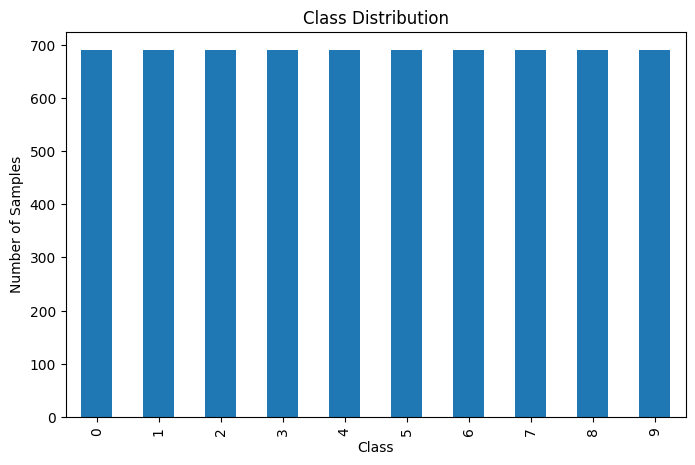

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

y.value_counts().sort_index().plot(kind='bar')

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5520, 256)
(1380, 256)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Logistic Regression


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.1108695652173913
              precision    recall  f1-score   support

           0       0.14      0.17      0.15       138
           1       0.08      0.09      0.09       138
           2       0.12      0.14      0.13       138
           3       0.15      0.12      0.13       138
           4       0.06      0.04      0.05       138
           5       0.13      0.13      0.13       138
           6       0.11      0.09      0.10       138
           7       0.13      0.13      0.13       138
           8       0.08      0.07      0.07       138
           9       0.10      0.12      0.11       138

    accuracy                           0.11      1380
   macro avg       0.11      0.11      0.11      1380
weighted avg       0.11      0.11      0.11      1380



###SVM

In [11]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print(classification_report(
    y_test,
    y_pred_svm
))

SVM Accuracy: 0.4007246376811594
              precision    recall  f1-score   support

           0       0.80      0.96      0.88       138
           1       0.38      0.32      0.35       138
           2       0.38      0.15      0.22       138
           3       0.29      0.41      0.34       138
           4       0.24      0.52      0.32       138
           5       0.56      0.33      0.41       138
           6       0.31      0.42      0.36       138
           7       0.33      0.25      0.28       138
           8       0.56      0.30      0.39       138
           9       0.50      0.36      0.42       138

    accuracy                           0.40      1380
   macro avg       0.43      0.40      0.40      1380
weighted avg       0.43      0.40      0.40      1380



In [12]:
C = [1, 10, 50, 100]

In [13]:
gamma = ['scale', 0.01, 0.001]

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_svm.best_params_)

print("Best CV Score:")
print(grid_svm.best_score_)

Best Parameters:
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score:
0.41992753623188406


In [15]:
best_svm = grid_svm.best_estimator_

y_pred = best_svm.predict(X_test_scaled)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred))

Test Accuracy: 0.41304347826086957


###Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest Accuracy: 0.39855072463768115
              precision    recall  f1-score   support

           0       0.76      0.93      0.83       138
           1       0.40      0.44      0.42       138
           2       0.35      0.23      0.28       138
           3       0.23      0.29      0.26       138
           4       0.30      0.43      0.35       138
           5       0.36      0.33      0.34       138
           6       0.32      0.36      0.34       138
           7       0.37      0.31      0.34       138
           8       0.48      0.30      0.37       138
           9       0.47      0.36      0.40       138

    accuracy                           0.40      1380
   macro avg       0.40      0.40      0.39      1380
weighted avg       0.40      0.40      0.39      1380



In [17]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

###XGBoost

In [18]:
!pip install xgboost

In [19]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=10,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print(classification_report(
    y_test,
    y_pred_xgb
))

XGBoost Accuracy: 0.4028985507246377
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       138
           1       0.39      0.46      0.42       138
           2       0.34      0.22      0.27       138
           3       0.26      0.31      0.28       138
           4       0.30      0.41      0.34       138
           5       0.39      0.37      0.38       138
           6       0.33      0.38      0.35       138
           7       0.37      0.29      0.33       138
           8       0.43      0.30      0.35       138
           9       0.45      0.41      0.43       138

    accuracy                           0.40      1380
   macro avg       0.41      0.40      0.40      1380
weighted avg       0.41      0.40      0.40      1380



###LightGBM

In [20]:
!pip install lightgbm

In [21]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM Accuracy:",
      accuracy_score(y_test, y_pred_lgbm))

print(classification_report(
    y_test,
    y_pred_lgbm
))

LightGBM Accuracy: 0.38768115942028986
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       138
           1       0.40      0.43      0.41       138
           2       0.26      0.20      0.23       138
           3       0.29      0.34      0.32       138
           4       0.29      0.37      0.32       138
           5       0.36      0.33      0.34       138
           6       0.30      0.33      0.32       138
           7       0.36      0.33      0.34       138
           8       0.40      0.30      0.34       138
           9       0.40      0.38      0.39       138

    accuracy                           0.39      1380
   macro avg       0.39      0.39      0.38      1380
weighted avg       0.39      0.39      0.38      1380



###Model Compare


In [22]:
from sklearn.metrics import f1_score

for name, pred in [
    ("Logistic Regression", y_pred_lr),
    ("SVM", y_pred_svm),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb),
    ("LightGBM", y_pred_lgbm)

]:

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')

    print(
        f"{name:20s} "
        f"Accuracy={acc:.4f} "
        f"Macro-F1={f1:.4f}"
    )

Logistic Regression  Accuracy=0.1109 Macro-F1=0.1094
SVM                  Accuracy=0.4007 Macro-F1=0.3955
Random Forest        Accuracy=0.3986 Macro-F1=0.3937
XGBoost              Accuracy=0.4029 Macro-F1=0.3997
LightGBM             Accuracy=0.3877 Macro-F1=0.3849


###Confusion Matrix
for XGBoost(best accuracy)

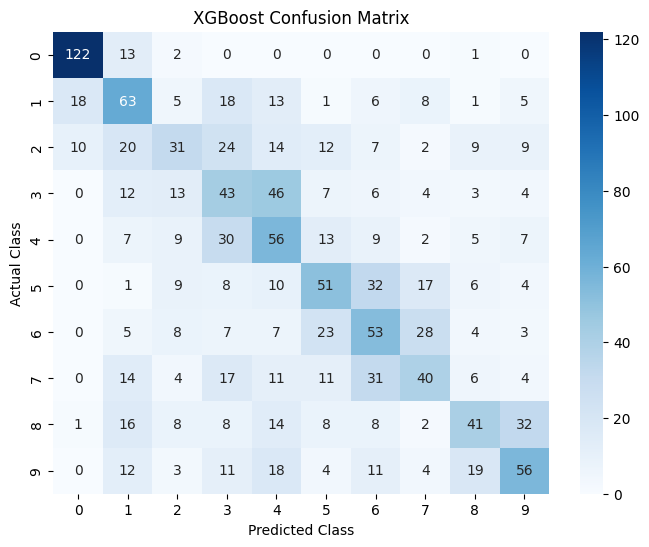

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("XGBoost Confusion Matrix")

plt.show()